1. Project Introduction

# 🌦️ Weather Data Analysis & Seasonal Trend Detection

## Objective
This project analyzes historical weather data to identify temperature trends, seasonal patterns, precipitation behavior, and extreme weather conditions using Python data analysis libraries.

2️. Import Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


3️. Load Dataset

In [11]:
df = pd.read_csv('/content/synthetic_weather_data.csv')

print(df.head())
print(df.info())
print(df.describe())
print(df.columns)

         Date  Temperature  Humidity  Precipitation
0  01-01-2020        13.28     53.28           2.64
1  02-01-2020         7.25     44.16           0.82
2  03-01-2020        14.32     88.80           0.57
3  04-01-2020        18.90     35.26           3.43
4  05-01-2020        20.73     33.08           1.81
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           1096 non-null   object 
 1   Temperature    1096 non-null   float64
 2   Humidity       1096 non-null   float64
 3   Precipitation  1096 non-null   float64
dtypes: float64(3), object(1)
memory usage: 34.4+ KB
None
       Temperature     Humidity  Precipitation
count  1096.000000  1096.000000    1096.000000
mean      9.905465    60.847828       3.468942
std      11.743029    17.376658       7.400378
min     -18.910000    30.000000       0.000000
25%       0.015000    46.

4️. Data Cleaning

In [12]:
print(df.isnull().sum())

df = df.dropna()

df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")
print(df.info())

Date             0
Temperature      0
Humidity         0
Precipitation    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1096 non-null   datetime64[ns]
 1   Temperature    1096 non-null   float64       
 2   Humidity       1096 non-null   float64       
 3   Precipitation  1096 non-null   float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 34.4 KB
None


5️. Descriptive Statistics (NumPy)

In [13]:
temp = df["Temperature"].values
humidity = df["Humidity"].values
precip = df["Precipitation"].values

print("Temperature:")
print("Mean:", np.mean(temp))
print("Median:", np.median(temp))
print("Standard Deviation:", np.std(temp))

print("\nHumidity:")
print("Mean:", np.mean(humidity))
print("Median:", np.median(humidity))
print("Standard Deviation:", np.std(humidity))

print("\nPrecipitation:")
print("Mean:", np.mean(precip))
print("Median:", np.median(precip))
print("Standard Deviation:", np.std(precip))


Temperature:
Mean: 9.905465328467153
Median: 9.065000000000001
Standard Deviation: 11.737670824712577

Humidity:
Mean: 60.847828467153285
Median: 60.480000000000004
Standard Deviation: 17.36872920584724

Precipitation:
Mean: 3.468941605839416
Median: 1.5150000000000001
Standard Deviation: 7.397001351175411


6️. Monthly Analysis

In [14]:
df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')[['Temperature', 'Humidity', 'Precipitation']].mean()
print(monthly_avg)

       Temperature   Humidity  Precipitation
Month                                       
1        13.771183  58.418925       3.015484
2        19.706353  59.859059       4.230471
3        25.317312  59.706022       3.737957
4        24.219667  62.078889       4.031111
5        21.172043  61.849247       2.258925
6        12.745667  58.691556       3.512333
7         5.828065  61.726667       3.151398
8        -0.290860  61.637634       3.271075
9        -4.412667  64.381333       2.455333
10       -3.732688  60.719570       3.238925
11       -0.448111  60.221111       4.183556
12        5.590215  60.862796       4.616129


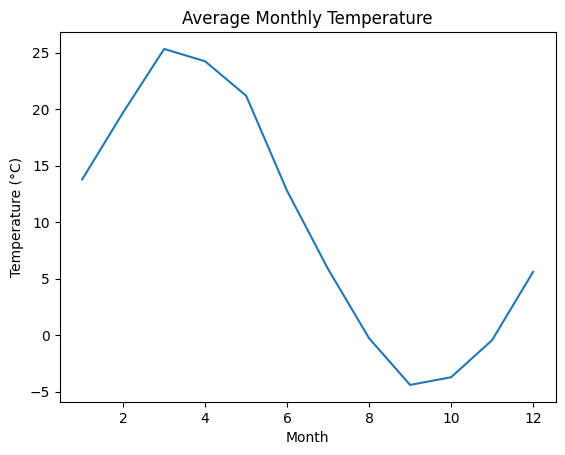

In [15]:
monthly_avg['Temperature'].plot(
    kind='line',
    title='Average Monthly Temperature'
)

plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.show()

7️. Precipitation Bar Plot

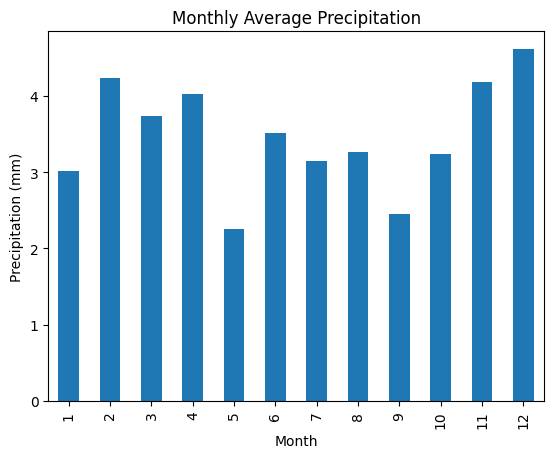

In [16]:
monthly_avg['Precipitation'].plot(
    kind='bar',
    title='Monthly Average Precipitation'
)

plt.xlabel('Month')
plt.ylabel('Precipitation (mm)')
plt.show()

8️. Temperature Distribution

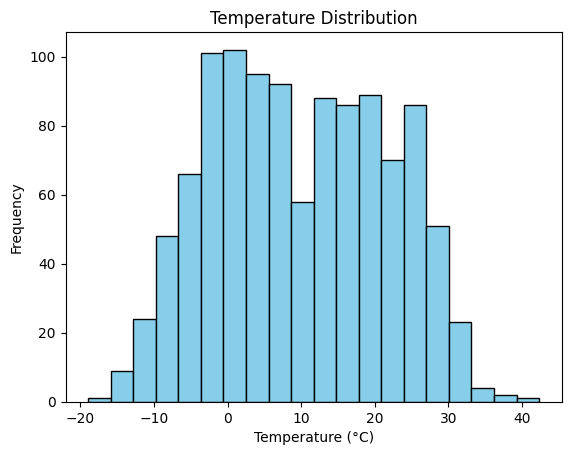

In [17]:
plt.hist(
    df['Temperature'],
    bins=20,
    color='skyblue',
    edgecolor='black'
)

plt.title('Temperature Distribution')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.show()


9️. Extreme Weather Detection

In [18]:
extreme_temp = df[np.abs(df['Temperature'] - df['Temperature'].mean()) > 2 * df['Temperature'].std()]
extreme_precip = df[df['Precipitation'] > df['Precipitation'].quantile(0.95)]

print("Extreme Temperature Days:")
print(extreme_temp)

print("\nExtreme Precipitation Days:")
print(extreme_precip)


Extreme Temperature Days:
           Date  Temperature  Humidity  Precipitation  Month
57   2020-02-27        35.19     50.39           0.88      2
78   2020-03-19        34.10     78.87           0.82      3
79   2020-03-20        36.92     37.97           1.76      3
92   2020-04-02        36.73     88.64           5.08      4
293  2020-10-20       -14.19     71.92           1.29     10
490  2021-05-05        42.30     44.95           0.73      5
629  2021-09-21       -14.70     67.87           4.36      9
655  2021-10-17       -15.28     67.57           1.30     10
846  2022-04-26        34.05     79.81           0.07      4
986  2022-09-13       -13.99     81.55           3.86      9
1005 2022-10-02       -18.91     77.80           0.82     10

Extreme Precipitation Days:
           Date  Temperature  Humidity  Precipitation  Month
9    2020-01-10        15.74     33.48          38.31      1
22   2020-01-23        12.72     40.39          14.19      1
28   2020-01-29        17.00  